In [23]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [24]:
def get_image(path, image_transform, size = (300,300)) :
    image = Image.open(path)
    image = image.resize(size, Image.LANCZOS)
    image = image_transform(image).unsqueeze(0)
    return image.to(device)

def get_gram(m) :
    _,c,h,w = m.size()
    m = m.view(c,h*w)
    m = torch.mm(m,m.t())
    return m

def denormalize_image(inp) :
    inp = inp.numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std*inp + mean
    inp = np.clip(inp,0,1)
    return inp

In [25]:
vgg = models.vgg16(pretrained=True)
vgg.features

C:\Users\tanma\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\tanma\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [26]:
vgg._modules.items() # ._modules ---> gives an ordered dictionary and .items() gives it's iterable form !

dict_items([('features', Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): C

In [27]:
class FeatureExtractor(nn.Module) : 
    def __init__(self) : 
        super(FeatureExtractor,self).__init__()
        self.selected_layers = [3,8,15,22]
        self.vgg = models.vgg16(pretrained = True).features
    def forward(self,x) :
        layer_features = []
        for (layer_num, layer) in self.vgg._modules.items() : 
            x = layer(x)
            if int(layer_num) in self.selected_layers :
                layer_features.append(x)
        return layer_features

In [28]:
img_transform = transforms.Compose([transforms.ToTensor(),
                                   transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))])
content_image = get_image("content.jpg", img_transform)
style_image = get_image("style.jpg", img_transform)
# generated_image = nn.Parameter(torch.FloatTensor(content_image.size())) # either initialize the generated image this way (some random tensor of size same as content image)
# or initialize it to same as content image (to have ZERO CONTENT LOSS at first iteration) !!!
generated_image = content_image.clone() # .clone() is used because without clone it will not be a true copy !!
# in the computational graph and while training the weights of generated image actually the content image weights are being updated !!
generated_image.requires_grad = True
optimizer = torch.optim.Adam([generated_image], lr = 0.003, betas = [0.5,0.999])
encoder = FeatureExtractor().to(device)

for p in encoder.parameters() : 
    p.requires_grad = False
# another way of doing this is encoder.eval() !! (this ensures that it is in evaluation mode) !

In [29]:
content_weight = 1
style_weight = 100
for epoch in range(500) :
    content_features = encoder(content_image)
    style_features = encoder(style_image)
    generated_features = encoder(generated_image)

    content_loss = torch.mean((content_features[-1]-generated_features[-1])**2)
    style_loss = 0
    for gf, sf in zip(generated_features,style_features) : 
        _,c,h,w = gf.size()
        gram_gf = get_gram(gf)
        gram_sf = get_gram(sf)
        style_loss += torch.mean((gram_gf-gram_sf)**2)/(c*h*w) # normalization !!
    loss = content_weight*content_loss + style_weight*style_loss
    optimizer.zero_grad()
    loss.backward() 
    optimizer.step()
    if epoch%10 == 0:
        print(f"Epoch [{epoch}] Content Loss : {content_loss:.4f}, Style Loss : {style_loss:.4f}")

Epoch [0] Content Loss : 0.0000, Style Loss : 289.4828
Epoch [10] Content Loss : 0.1452, Style Loss : 197.1789
Epoch [20] Content Loss : 0.3445, Style Loss : 151.3130
Epoch [30] Content Loss : 0.5166, Style Loss : 122.7913
Epoch [40] Content Loss : 0.6583, Style Loss : 103.0355
Epoch [50] Content Loss : 0.7717, Style Loss : 88.3989
Epoch [60] Content Loss : 0.8594, Style Loss : 77.0957
Epoch [70] Content Loss : 0.9339, Style Loss : 68.0727
Epoch [80] Content Loss : 0.9980, Style Loss : 60.6828
Epoch [90] Content Loss : 1.0540, Style Loss : 54.5059
Epoch [100] Content Loss : 1.1047, Style Loss : 49.2525
Epoch [110] Content Loss : 1.1515, Style Loss : 44.7310
Epoch [120] Content Loss : 1.1926, Style Loss : 40.7987
Epoch [130] Content Loss : 1.2314, Style Loss : 37.3520
Epoch [140] Content Loss : 1.2643, Style Loss : 34.3131
Epoch [150] Content Loss : 1.2955, Style Loss : 31.6159
Epoch [160] Content Loss : 1.3252, Style Loss : 29.2138
Epoch [170] Content Loss : 1.3520, Style Loss : 27.065

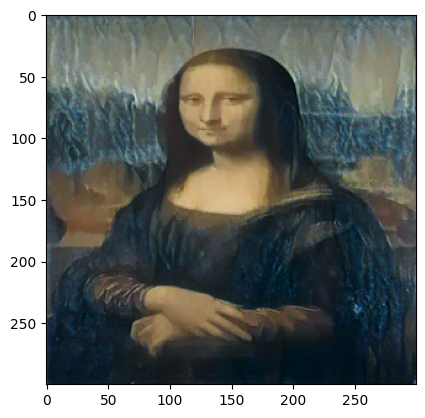

In [30]:
inp = generated_image.detach().cpu().squeeze()
inp = denormalize_image(inp)
plt.imshow(inp)